# Notebook 4. The shape of the relation, and how much is noise

**Question.** Among runs that grok, how does the grokking step depend on the kernel statistics `A_t`, `S_t` and `R_t`? Is the relation a straight line, what shape does it take, do the statistics interact, and how much of the data is noise?

Notebook 3 used all runs, including runs that never grok, and asked whether the statistics rank runs from a new `alpha`. Here the main tool is kernel ridge regression, which fits a smooth surface with no shape fixed in advance. We compare it with simpler models to see what each kind of shape adds.

An interaction term here is the product of two standardised statistics: $z_A z_S$, $z_A z_R$ or $z_S z_R$. It lets the effect of one statistic depend on another. As in notebook 3, the models use log `R_t` (Part 1 explains why).

**Short answer.**
- **Seed noise is small.** 96% of the spread in $\log T$ lies between cells and only 4% between seeds of a cell. `S_t` and `R_t` are almost entirely set by the settings, and `A_t` about half. Within a cell, none of them follows the seed noise.
- **The relation is non-linear, with two simple bends.** A straight line explains 31% of $\log T$ on held-out cells. Using log `R_t` and adding a square of `S_t` lifts this to 50%, close to one free curve per statistic (52%).
- **Among grokked runs the statistics interact only a little.** Adding interaction terms lifts the curves from 52% to 54%, and kernel ridge reaches 55%. These gains are at the edge of our noise level. Interactions matter more for whether a run groks at all.
- **`R_t` carries the most information.** Without it, kernel ridge falls from 55% to 23%.
- **The settings predict better than the kernel.** XGBoost on the settings alone explains 93%, close to the 96% ceiling set by seed noise.

## Words used in this notebook

| Term | Meaning |
| --- | --- |
| grokking step `T` | The first saved step at which test accuracy reaches 0.95 (golden report §3.5). |
| cell | One mix of `alpha`, width and weight decay. Each cell has 5 seeds. |
| `S_t`, `R_t`, `A_t` | Kernel scale, rotation and alignment at step t (golden report Eq. 6). `S_t` is the kernel's size relative to the start (1 means no change). `R_t` is one minus the cosine between the kernel now and at the start (0 means the same shape). `A_t` is the alignment with the labels of the 53 test pairs. |
| prediction time $t^*$ | Step 2,430, before every run groks. The statistics are read here. |
| cross-sectional covariates | The three statistics at $t^*$. Parts 1 to 6 use these. |
| longitudinal covariates | The statistics at all 25 saved steps up to $t^*$. Part 7 uses them. |
| standardised | Minus the mean and divided by the standard deviation of the training runs. We write $z_A$, $z_S$, $z_R$. |
| between-cell and within-cell spread | The spread of a quantity splits in two: how much the cell averages differ (set by the settings), and how much the seeds of one cell differ from their average (seed noise). |
| $R^2$ | The share of the spread in $\log T$ that a model explains on held-out runs. 1 is perfect, 0 is no better than the mean, and below 0 is worse than the mean. |
| concordance | Pick two runs. It is the share of pairs that the model puts in the right order. 0.5 is a coin toss and 1 is perfect. |
| additive model | $\log T = \beta_0 + f_A(z_A) + f_S(z_S) + f_R(z_R)$. Each statistic has its own curve, and none changes the effect of another. |
| interaction term | The product of two standardised statistics: $z_A z_S$, $z_A z_R$ or $z_S z_R$. With the term $\gamma_{AS} z_A z_S$, the slope of $\log T$ in $z_A$ changes by $\gamma_{AS}$ for each standard deviation of $z_S$. |
| partial dependence | The model's average prediction as one statistic slides from low to high, with the other two left at each run's own values. |

## How the models are tested

**Which runs.** Parts 1 to 5 and Part 7 use the 355 runs that grokked, because their $\log T$ is a known number. This selects the faster runs, most of all at `alpha` 2, where only 47 of 210 runs grok. So these parts answer "when does a run grok, given that it groks?". Part 6 uses all 630 runs.

**No random train/test split of runs.** The 5 seeds of a cell are near copies. A random split would put copies on both sides and reward remembering cells. Every score holds out a whole group instead.
- **Hold out one cell.** 75 folds over the grokked runs, 126 over all runs. The model has seen cells with nearby settings, so this tests the shape of the fit inside the range of the data.
- **Hold out one `alpha`.** 3 folds, as in notebook 3. This tests a value of `alpha` the model has never seen. We report the concordance on each held-out `alpha` and the mean of the three.

Fits on all grokked runs, such as the curves of Part 4, describe the data and make no claim about prediction.

**Choosing model settings.** Settings are always chosen inside the training runs of a fold.
- The ridge penalty of the linear-with-penalty and spline models is chosen from 13 values by leave-one-run-out cross-validation (`RidgeCV`). That leaves out single runs, while the other seeds of the cell stay in. On the earlier data we checked a choice that leaves out whole cells instead, and it made no practical difference.
- Kernel ridge chooses its penalty and width by 5-fold cross-validation that holds out whole cells.
- XGBoost in Part 7 holds out 20% of the training cells as a validation set, tries 24 settings with early stopping, and keeps the one with the lowest validation error.
- Part 6 fixes every setting in advance, so the two models in each pair differ only in whether the statistics may interact.

These notebooks are exploratory and compare many models, so treat small gaps (below about 0.02 in $R^2$ or 0.03 in concordance) as noise.

## Setup

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from joblib import Parallel, delayed
from lifelines import LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.compose import TransformedTargetRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline, make_union
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler

plt.style.use('fitting.mplstyle')
GREY, INK, PALE = '#8a8984', '#0b0b0b', '#c8c7c2'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06', 'log R_t': '#c99a06'}
ALPHA_COLOURS = {0.5: '#2a78d6', 1.0: '#0b0b0b', 2.0: '#eb6834'}
kernel = ['A_t', 'S_t', 'R_t']                                          # the statistics as stored
covs = ['A_t', 'S_t', 'log R_t']                                        # what the models use (Part 1 explains log R_t)
cov_pairs = [('A_t', 'S_t'), ('A_t', 'log R_t'), ('S_t', 'log R_t')]
T_STAR = 2_430                                                          # prediction time t*

## Load the data

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

events = runs.set_index('run_id')
events['T'] = acc[acc['test_acc'] >= 0.95].groupby('run_id')['step'].min()
events = events.reset_index()
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

everything = events.merge(kern[kern['step'] == T_STAR].drop(columns='step'), on='run_id')
everything = everything[everything['eta_kappa'] <= 1e-3].reset_index(drop=True)
everything['log R_t'] = np.log(everything['R_t'])
data = everything.dropna(subset=['T']).reset_index(drop=True)     # grokked runs only
log_T = np.log(data['T'])
assert data['T'].min() > T_STAR
data.groupby('alpha').size().rename('grokked runs')

alpha
0.5    178
1.0    130
2.0     47
Name: grokked runs, dtype: int64

## Part 1. Look at the data

**Question.** What does each statistic look like against the grokking step?

Each dot is a grokked run, coloured by `alpha`. A straight-line relation would show as a tilted band. `R_t` is drawn on a log axis because it spans three orders of magnitude.

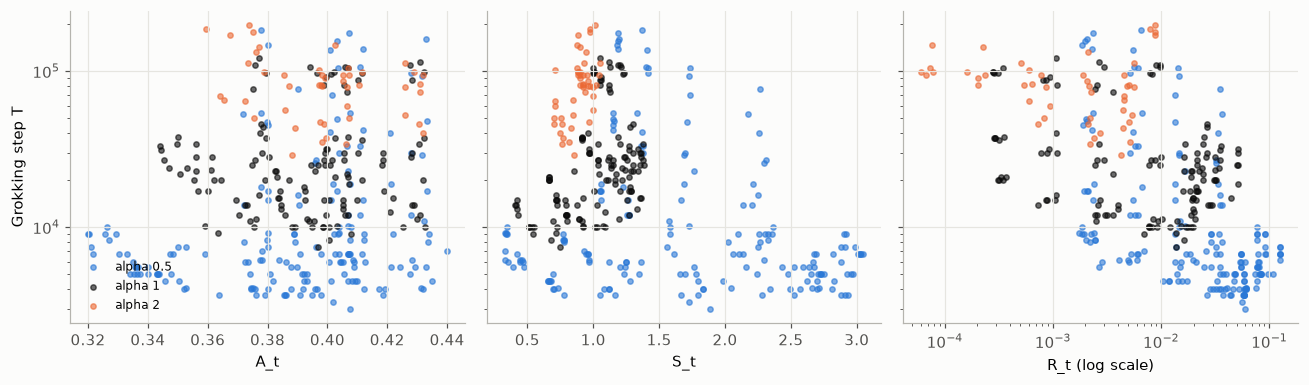

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, stat in zip(axes, kernel):
    for a, g in data.groupby('alpha'):
        ax.scatter(g[stat], g['T'], s=12, color=ALPHA_COLOURS[a], alpha=0.6, label=f'alpha {a:g}')
    ax.set_yscale('log')
    ax.set_xlabel(stat)
axes[2].set_xscale('log')
axes[2].set_xlabel('R_t (log scale)')
axes[0].set_ylabel('Grokking step T')
axes[0].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

**What this shows**
- Each `alpha` sits in its own patch. `alpha` 2 (orange) bunches at small `S_t` and `R_t` and groks late. `alpha` 0.5 (blue) spreads wide and groks early.
- On a log axis, `R_t` against `T` looks like a falling band. On its own scale it would bunch up near 0. This is why the models use log `R_t`.
- `S_t` shows no single band, and `A_t` sits mostly between 0.35 and 0.43.

## Part 2. How much is signal and how much is noise?

**Question.** The 5 seeds of a cell share every setting. How much of the spread in $\log T$ and in each statistic comes from the settings, and how much from the seed?

For each quantity we split its spread in two. The between-cell part is how much the cell averages differ. The within-cell part is how much seeds differ from their cell average, which is seed noise. We also ask how much a single setting explains when it is used on its own.

The saved checkpoints also round `T` up to the next saved step, which adds a small measurement error. The cell prints its size.

Rounding T up to a saved step adds about 0.03% of the spread of log T.


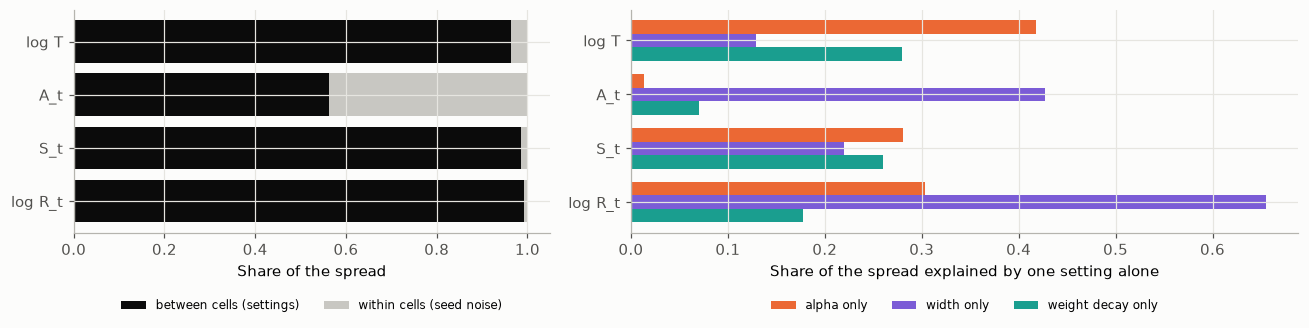

,alpha only,width only,weight decay only,all three (the cell),seed noise
log T,0.418,0.129,0.280,0.964,0.036
A_t,0.013,0.427,0.070,0.563,0.437
S_t,0.280,0.219,0.260,0.987,0.013
log R_t,0.304,0.655,0.177,0.993,0.007


In [4]:
values = {'log T': log_T, 'A_t': data['A_t'], 'S_t': data['S_t'], 'log R_t': data['log R_t']}
groupings = {'alpha only': 'alpha', 'width only': 'width', 'weight decay only': 'eta_kappa', 'all three (the cell)': 'cell'}
explained = pd.DataFrame({name: {label: 1 - ((v - v.groupby(data[key]).transform('mean')) ** 2).sum() / ((v - v.mean()) ** 2).sum()
                                 for label, key in groupings.items()} for name, v in values.items()}).T
explained['seed noise'] = 1 - explained['all three (the cell)']

steps = np.sort(acc['step'].unique())
previous = steps[np.searchsorted(steps, data['T']) - 1]     # T lies somewhere after the previous saved step
rounding = ((log_T - np.log(previous)) ** 2 / 12).mean() / log_T.var()
print(f'Rounding T up to a saved step adds about {rounding:.2%} of the spread of log T.')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw={'width_ratios': [1, 1.4]})
axes[0].barh(explained.index, explained['all three (the cell)'], color=INK, label='between cells (settings)')
axes[0].barh(explained.index, explained['seed noise'], left=explained['all three (the cell)'], color=PALE, label='within cells (seed noise)')
axes[0].set_xlabel('Share of the spread')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=8)
axes[0].invert_yaxis()
width = 0.25
for j, (label, colour) in enumerate(zip(['alpha only', 'width only', 'weight decay only'], [ALPHA_COLOURS[2.0], KERNEL_COLOURS['A_t'], KERNEL_COLOURS['S_t']])):
    axes[1].barh(np.arange(len(explained)) + (j - 1) * width, explained[label], height=width, color=colour, label=label)
axes[1].set_yticks(range(len(explained)), explained.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Share of the spread explained by one setting alone')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()
explained.round(3)

How the settings move `S_t` and `R_t`. Each square is the median over the seeds of a cell. All 630 runs are used here, grokked or not.

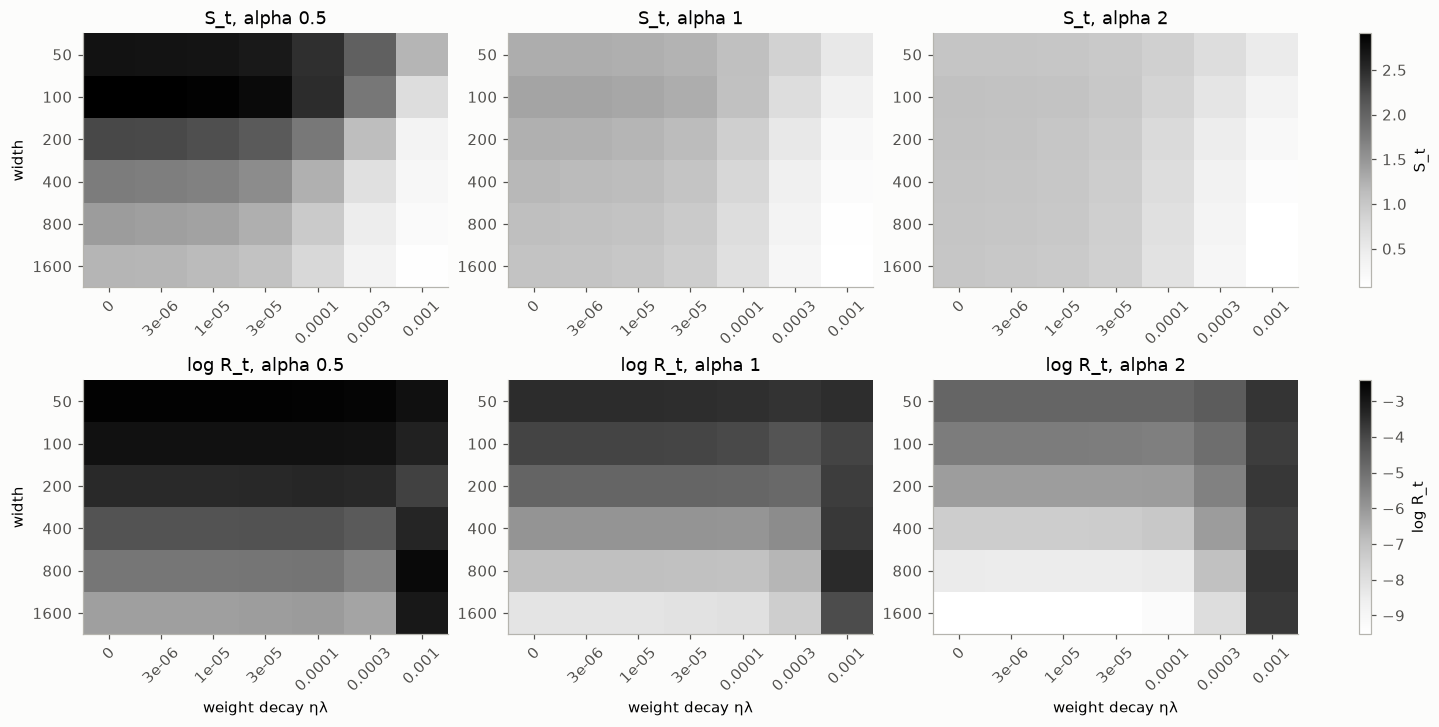

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), layout='constrained')
for row, stat in enumerate(['S_t', 'log R_t']):
    for ax, a in zip(axes[row], sorted(everything['alpha'].unique())):
        grid = everything[everything['alpha'] == a].pivot_table(index='width', columns='eta_kappa', values=stat, aggfunc='median')
        im = ax.imshow(grid, cmap='Greys', aspect='auto', vmin=everything[stat].quantile(0.02), vmax=everything[stat].quantile(0.98))
        ax.set_xticks(range(grid.shape[1]), [f'{w:g}' for w in grid.columns], rotation=45)
        ax.set_yticks(range(grid.shape[0]), grid.index)
        ax.set_title(f'{stat}, alpha {a:g}')
        ax.grid(False)
        if a == 0.5:
            ax.set_ylabel('width')
    fig.colorbar(im, ax=axes[row], label=stat)
for ax in axes[1]:
    ax.set_xlabel('weight decay ηλ')
plt.show()

Last, do the statistics follow the seed noise? We subtract each cell's average from every run, for $\log T$ and for each statistic, and plot what is left. A clear slope would mean the kernel tells seeds of the same cell apart.

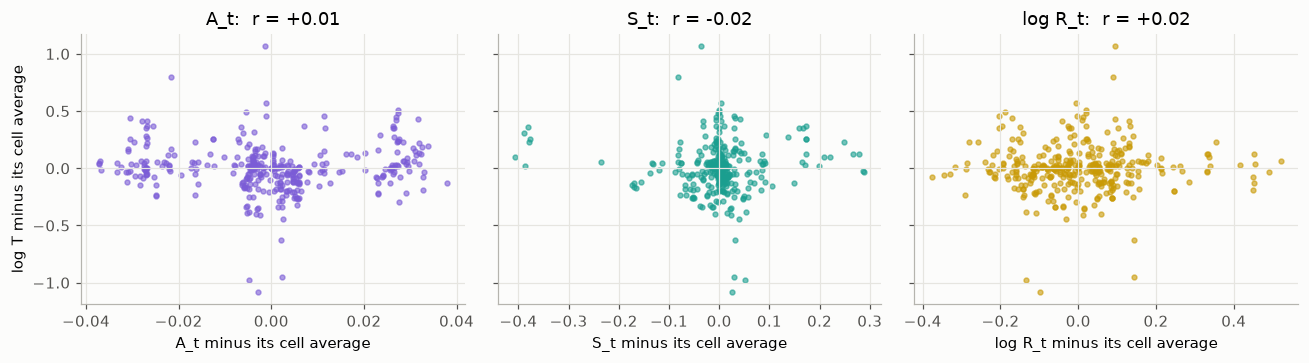

In [6]:
within_T = log_T - log_T.groupby(data['cell']).transform('mean')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, stat in zip(axes, covs):
    within = data[stat] - data[stat].groupby(data['cell']).transform('mean')
    ax.scatter(within, within_T, s=10, color=KERNEL_COLOURS[stat], alpha=0.6)
    ax.set_title(f'{stat}:  r = {np.corrcoef(within, within_T)[0, 1]:+.2f}')
    ax.set_xlabel(f'{stat} minus its cell average')
axes[0].set_ylabel('log T minus its cell average')
plt.tight_layout()
plt.show()

**What this shows**
- Seed noise is small. 96% of the spread in $\log T$ lies between cells and only 3.6% within them. Rounding `T` to the checkpoint grid adds 0.03%. So a model that knew each cell's average would reach $R^2$ of about 0.96. That is the ceiling for any model on these runs.
- `S_t` and log `R_t` are almost pure readouts of the settings: 98.7% and 99.3% of their spread lies between cells. `A_t` has much more seed noise (44%). `A_t` is measured on the test pairs, and each seed now has its own split. On the earlier data, where every seed shared one split, its seed noise was 11%. So most of it comes from the split.
- No setting acts alone. Used on its own, `alpha` explains 42% of $\log T$, weight decay 28% and width 13%. Together these come to about 83%, while the full cell explains 96%, which suggests the settings also combine. Width explains the largest share of `A_t` (43%) and of log `R_t` (66%). The spread of `S_t` is shared among the three settings.
- In the maps, weight decay shrinks the kernel (`S_t` falls as weight decay rises), and at `alpha` 0.5 narrow networks grow the most. Narrow networks rotate the most, and weight decay 1e-3 makes every network rotate more.
- Within a cell, the statistics do not follow the seed noise (r = 0.01, −0.02 and 0.02). So they describe differences between cells, and say almost nothing about why one seed groks before another.
- For modelling, the signal in the kernel statistics is mostly the settings seen through the kernel. The question for the rest of this notebook is how much of the cell-level grokking time they recover, against the ceiling of 0.96.

## Part 3. What kind of curve? A ladder of models

**Question.** Is the relation a straight line? If not, what is the simplest model that captures it?

Each step up the ladder allows one more kind of shape. With $z_A$, $z_S$, $z_R$ the standardised statistics:
1. **Linear, raw `R_t`.** $\beta_0 + \beta_A z_A + \beta_S z_S + \beta_R z_R$ with `R_t` on its own scale.
2. **Linear.** The same with log `R_t` in place of `R_t`. From here on, $z_R$ is the standardised log `R_t`.
3. **Linear + $S_t^2$.** Model 2 plus a square of `S_t`, which lets the `S_t` curve rise and fall.
4. **Additive splines.** $\beta_0 + f_A(z_A) + f_S(z_S) + f_R(z_R)$, each $f$ a cubic spline with 5 knots. Any smooth bend, but no interactions.
5. **Splines + products.** Model 4 plus $\gamma_{AS} z_A z_S + \gamma_{AR} z_A z_R + \gamma_{SR} z_S z_R$.
6. **Kernel ridge regression** with an RBF kernel. Any smooth surface, with interactions of every order.

If a step beats the one before it, the shape it adds is real. Kernel ridge has no intercept, so far from the data its prediction falls to 0. We therefore subtract the mean of $\log T$ before fitting and add it back after.

In [7]:
data['S_t²'] = data['S_t'] ** 2
linear = lambda: make_pipeline(StandardScaler(), LinearRegression())
splines = lambda: make_pipeline(StandardScaler(), SplineTransformer(n_knots=5, degree=3), RidgeCV(np.logspace(-3, 3, 13)))
splines_products = lambda: make_pipeline(StandardScaler(), make_union(SplineTransformer(n_knots=5, degree=3),
                                                                      PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                         RidgeCV(np.logspace(-3, 3, 13)))
kernel_ridge = lambda: TransformedTargetRegressor(
    GridSearchCV(make_pipeline(StandardScaler(), KernelRidge(kernel='rbf')),
                 {'kernelridge__alpha': [0.01, 0.1, 1], 'kernelridge__gamma': [0.1, 0.5, 2]}, cv=GroupKFold(5)),
    transformer=StandardScaler())
ladder = {     # name: (model, covariates)
    'linear, raw R_t': (linear, kernel),
    'linear': (linear, covs),
    'linear + S_t²': (linear, ['A_t', 'S_t', 'S_t²', 'log R_t']),
    'additive splines': (splines, covs),
    'splines + products': (splines_products, covs),
    'kernel ridge': (kernel_ridge, covs),
}

pred = {}
for hide in ['cell', 'alpha']:
    for name, (make, cols) in ladder.items():
        p = pd.Series(index=data.index, dtype=float)
        for group in data[hide].unique():
            train, test = data[hide] != group, data[hide] == group
            extra = {'groups': data.loc[train, 'cell']} if name == 'kernel ridge' else {}
            p[test] = make().fit(data.loc[train, cols], log_T[train], **extra).predict(data.loc[test, cols])
        pred[hide, name] = p
LADDER_COLOURS = [PALE, GREY, KERNEL_COLOURS['S_t'], INK, INK, KERNEL_COLOURS['A_t']]

### Hold out one cell

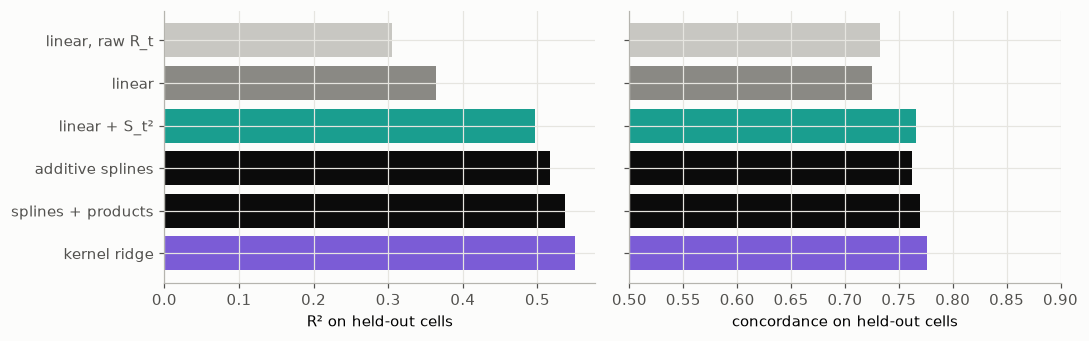

,R²,concordance
"linear, raw R_t",0.305,0.733
linear,0.364,0.726
linear + S_t²,0.497,0.766
additive splines,0.517,0.762
splines + products,0.537,0.770
kernel ridge,0.550,0.776


In [8]:
scores = pd.DataFrame({name: {'R²': r2_score(log_T, pred['cell', name]), 'concordance': concordance_index(log_T, pred['cell', name])}
                       for name in ladder}).T

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, col in zip(axes, scores):
    ax.barh(scores.index, scores[col], color=LADDER_COLOURS)
    ax.set_xlabel(col + ' on held-out cells')
axes[0].invert_yaxis()
axes[1].set_xlim(0.5, 0.9)
plt.tight_layout()
plt.show()
scores.round(3)

**What this shows**
- A straight line on raw `R_t` explains 31% (R² 0.305). Using log `R_t` lifts this to 36%, and adding a square of `S_t` lifts it to 50% (0.497). That is close to the additive splines (0.517), which allow any smooth curve for each statistic. **So two simple bends capture most of the curvature: a log curve in `R_t` and a rise and fall in `S_t`.**
- Adding the three interaction terms to the splines lifts R² to 0.537, and kernel ridge reaches 0.550. **So among grokked runs the statistics interact only a little.** Each gain is about 0.02, which is our noise level.
- The concordance moves little (0.76 to 0.77 to 0.78).
- The best kernel model explains 55%, against the ceiling of 96% from Part 2.

### Hold out one `alpha`

We score each held-out `alpha` on its own. The table also gives $R^2$ over all three folds, which asks whether the model gets the actual step right. A good ranking does not need that.

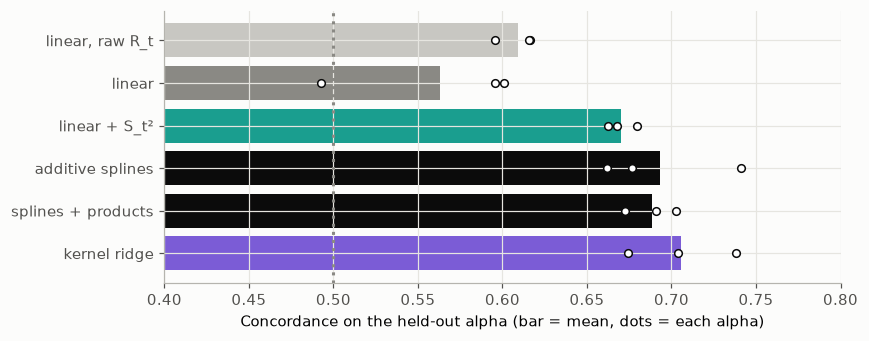

,alpha 0.5,alpha 1,alpha 2,mean concordance,R²
"linear, raw R_t",0.617,0.596,0.616,0.609,-0.785
linear,0.493,0.601,0.595,0.563,-1.980
linear + S_t²,0.668,0.680,0.663,0.670,-0.583
additive splines,0.662,0.677,0.741,0.693,-0.043
splines + products,0.691,0.672,0.703,0.689,0.109
kernel ridge,0.674,0.704,0.738,0.706,-0.159


In [9]:
rows = {}
for name in ladder:
    p = pred['alpha', name]
    rows[name] = {f'alpha {a:g}': concordance_index(log_T[data['alpha'] == a], p[data['alpha'] == a]) for a in sorted(data['alpha'].unique())}
    rows[name]['mean concordance'] = np.mean(list(rows[name].values()))
    rows[name]['R²'] = r2_score(log_T, p)
alpha_scores = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(alpha_scores.index, alpha_scores['mean concordance'], color=LADDER_COLOURS)
for i, (name, row) in enumerate(alpha_scores.iterrows()):
    ax.scatter(row[['alpha 0.5', 'alpha 1', 'alpha 2']], [i] * 3, color='white', edgecolors=INK, s=25, zorder=3)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.set_xlim(0.4, 0.8)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the held-out alpha (bar = mean, dots = each alpha)')
plt.tight_layout()
plt.show()
alpha_scores.round(3)

Why can $R^2$ fall below 0 while the ranking stays good? Here are the predictions against the truth. A model can get the order right and still shift every run of a held-out `alpha` up or down.

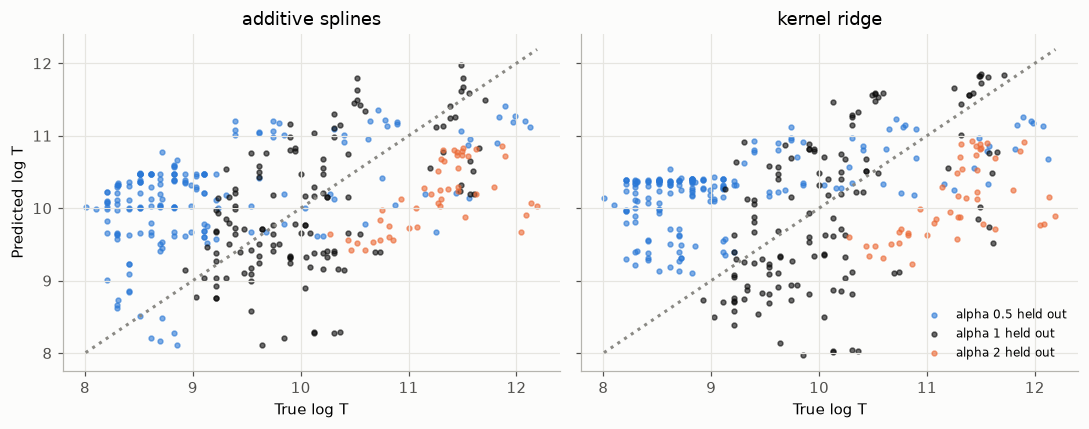

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, name in zip(axes, ['additive splines', 'kernel ridge']):
    for a in sorted(data['alpha'].unique()):
        m = data['alpha'] == a
        ax.scatter(log_T[m], pred['alpha', name][m], s=10, color=ALPHA_COLOURS[a], alpha=0.6, label=f'alpha {a:g} held out')
    lims = [log_T.min(), log_T.max()]
    ax.plot(lims, lims, color=GREY, linestyle=':')
    ax.set_xlabel('True log T')
    ax.set_title(name)
axes[0].set_ylabel('Predicted log T')
axes[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**What this shows**
- On a new `alpha`, kernel ridge (0.706) and the additive splines (0.693) rank runs best, and the linear model with `S_t`² is close behind (0.670). Adding interaction terms to the splines adds nothing here (0.689 against 0.693).
- Log `R_t` alone does not help on a new `alpha` (0.563 against 0.609 for raw `R_t`). It helps once `S_t` can bend as well.
- $R^2$ is near or below 0 for every model, even when the order is right. The plot shows why. Held-out `alpha` 2 runs (orange) are predicted too early and held-out `alpha` 0.5 runs (blue) too late. Each `alpha` has its own baseline that the statistics do not carry.

## Part 4. What shape is each curve?

**Question.** For each statistic, how does the predicted grokking step change as it grows?

We fit kernel ridge and the additive splines once on all grokked runs and draw each statistic's partial dependence: slide it from low to high, keep the other two at each run's own values, and average the predictions. Where the two models agree, the shape does not depend on the model.

kernel ridge settings: {'kernelridge__alpha': 0.1, 'kernelridge__gamma': 0.1}


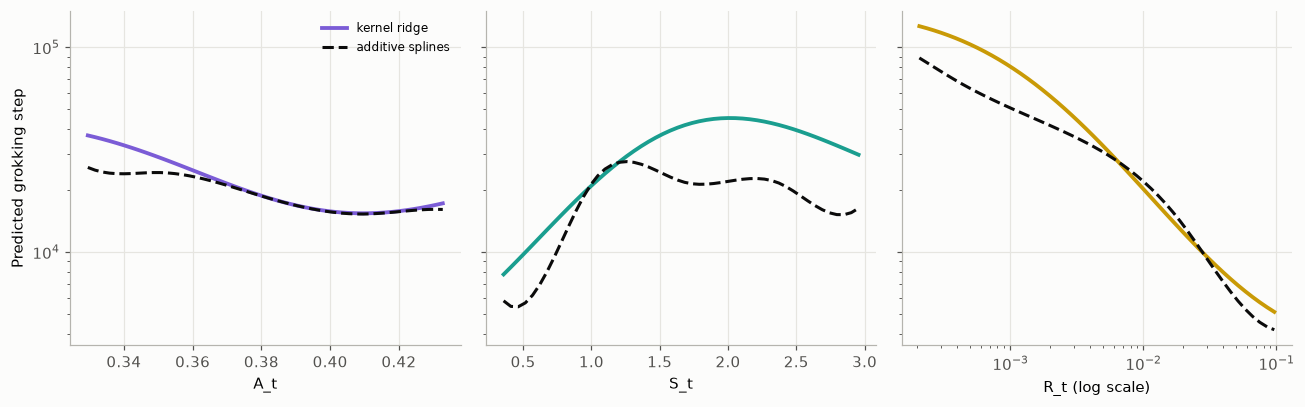

In [11]:
krr = kernel_ridge().fit(data[covs], log_T, groups=data['cell'])
spl = splines().fit(data[covs], log_T)
print('kernel ridge settings:', krr.regressor_.best_params_)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, stat in zip(axes, covs):
    grid = np.linspace(data[stat].quantile(0.02), data[stat].quantile(0.98), 50)
    for model, style in [(krr, dict(color=KERNEL_COLOURS[stat], linewidth=2.5, label='kernel ridge')),
                         (spl, dict(color=INK, linestyle='--', label='additive splines'))]:
        curve = []
        for v in grid:
            X = data[covs].copy()
            X[stat] = v
            curve.append(model.predict(X).mean())
        ax.plot(np.exp(grid) if stat == 'log R_t' else grid, np.exp(curve), **style)
    ax.set_yscale('log')
    ax.set_xlabel(stat.replace('log ', ''))
axes[2].set_xscale('log')
axes[2].set_xlabel('R_t (log scale)')
axes[0].set_ylabel('Predicted grokking step')
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**What this shows**
- **`A_t`.** Both models agree that more alignment means sooner grokking up to about 0.40. Above that the curves are flat.
- **`R_t`.** Both models agree on a steep fall from about $2 \times 10^{-4}$ to 0.1. On the log axis the fall is close to a straight line, which is why log `R_t` works.
- **`S_t`.** The models agree only between about 0.5 and 1.2, where the predicted step rises. Above 1.2 they disagree: kernel ridge keeps rising up to about 2 and the splines fall. Only `alpha` 0.5 runs have `S_t` that large, so the shape there is unknown. Notebook 3 (Part 4), which also uses runs that never grok, finds the earliest grokking near `S_t` 0.7 to 0.95.
- Kernel ridge chose a smooth surface (penalty 0.1, width 0.1 on the standardised statistics).

## Part 5. Which statistic carries the most information?

**Question.** If we remove one statistic, can the other two make up for it?

We refit kernel ridge without each statistic in turn and score it on held-out cells. A large drop in $R^2$ means the other two cannot replace the missing one.

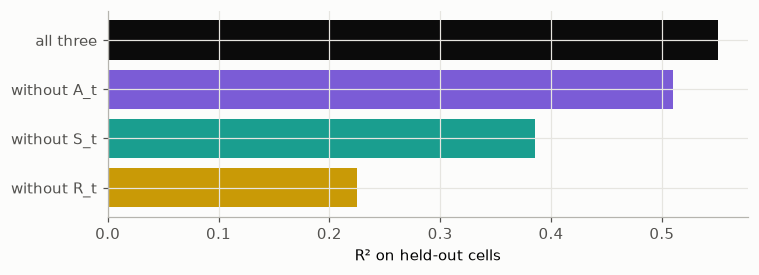

,R² on held-out cells,concordance
all three,0.550,0.776
without A_t,0.510,0.756
without S_t,0.386,0.725
without R_t,0.225,0.653


In [12]:
dropped = {'all three': covs, 'without A_t': ['S_t', 'log R_t'], 'without S_t': ['A_t', 'log R_t'], 'without R_t': ['A_t', 'S_t']}
rows = {}
for name, cols in dropped.items():
    p = pd.Series(index=data.index, dtype=float)
    for group in data['cell'].unique():
        train, test = data['cell'] != group, data['cell'] == group
        p[test] = kernel_ridge().fit(data.loc[train, cols], log_T[train], groups=data.loc[train, 'cell']).predict(data.loc[test, cols])
    rows[name] = {'R² on held-out cells': r2_score(log_T, p), 'concordance': concordance_index(log_T, p)}
dropped = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(dropped.index, dropped['R² on held-out cells'], color=[INK] + [KERNEL_COLOURS[k] for k in kernel])
ax.invert_yaxis()
ax.set_xlabel('R² on held-out cells')
plt.tight_layout()
plt.show()
dropped.round(3)

### Two statistics at once

The map shows the kernel ridge prediction as `S_t` and `R_t` change together, with `A_t` at its median. The dots are the runs. Away from the dots the map is a guess.

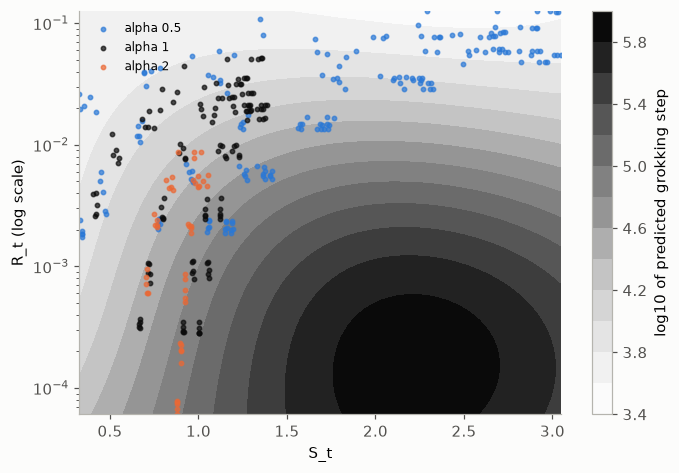

In [13]:
S, logR = np.meshgrid(np.linspace(data['S_t'].min(), data['S_t'].max(), 60), np.linspace(data['log R_t'].min(), data['log R_t'].max(), 60))
probe = pd.DataFrame({'A_t': data['A_t'].median(), 'S_t': S.ravel(), 'log R_t': logR.ravel()})
surface = krr.predict(probe).reshape(S.shape) / np.log(10)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
im = ax.contourf(S, np.exp(logR), surface, levels=12, cmap='Greys')
for a, g in data.groupby('alpha'):
    ax.scatter(g['S_t'], g['R_t'], s=8, color=ALPHA_COLOURS[a], alpha=0.7, label=f'alpha {a:g}')
fig.colorbar(im, label='log10 of predicted grokking step')
ax.set_yscale('log')
ax.set_xlabel('S_t')
ax.set_ylabel('R_t (log scale)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.show()

**What this shows**
- Removing `R_t` hurts most: R² falls from 0.550 to 0.225. Removing `S_t` (0.386) or `A_t` (0.510) hurts less. **`R_t` carries the most information that the other two cannot replace.**
- On the map the bands run diagonally. As `S_t` grows, more rotation is needed for the same predicted step. That is the `S_t` × `R_t` interaction of notebook 3: a kernel that grows without rotating is predicted to grok late.
- The dark corner at large `S_t` and small `R_t` has no runs, so it is a guess.

## Part 6. Do the statistics interact? It depends on the question

**Question.** Part 3 asks about grokked runs only. Notebook 3 also counts runs that never grok. Do interactions matter for both?

We ask three questions and answer each with two model families:

| Question | Runs | Score |
| --- | --- | --- |
| Does the run grok at all? | all 630 | AUC (0.5 = coin toss) |
| When does it grok, counting "never" as "after 200,000"? | all 630 | concordance |
| When does a grokked run grok? | the 355 that grokked | concordance |

Each family comes in two versions that differ only in whether the statistics may interact:
- **Splines.** One curve per statistic, or the same curves plus the three products $z_A z_S$, $z_A z_R$, $z_S z_R$. The model is a logistic regression for the first question, an AFT for the second, and a regression on $\log T$ for the third.
- **XGBoost.** Trees of depth 1 (each tree splits on one statistic, so no interactions) or depth 3 (a tree can split on two or three in a row).

The gain is the score with interactions minus the score without. Whether a run groks is almost a property of its cell: in only 5 of 126 cells do some seeds grok and others not.

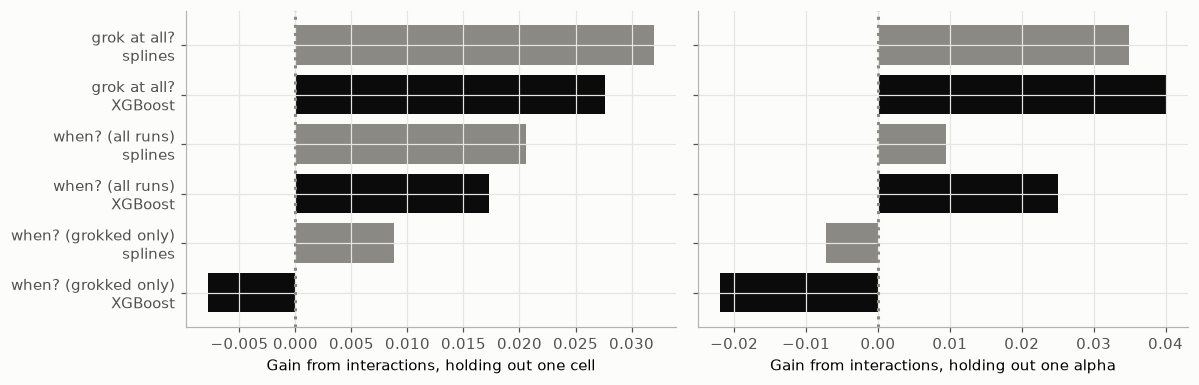

hide                             cell                        alpha  \
shape                        additive interactions   gain additive   
question             family                                          
grok at all?         splines    0.759        0.791  0.032    0.725   
                     XGBoost    0.800        0.828  0.028    0.768   
when? (all runs)     splines    0.755        0.776  0.021    0.683   
                     XGBoost    0.761        0.778  0.017    0.690   
when? (grokked only) splines    0.763        0.771  0.009    0.692   
                     XGBoost    0.753        0.745 -0.008    0.704   

hide                                              
shape                        interactions   gain  
question             family                       
grok at all?         splines        0.760  0.035  
                     XGBoost        0.808  0.040  
when? (all runs)     splines        0.693  0.009  
                     XGBoost        0.715  0.025  
when? (grokked only) splines        0.685 -0.007  
                     XGBoost        0.682 -0.022

In [14]:
everything['grokked'] = everything['T'].notna().astype(int)
everything['T_or_budget'] = everything['T'].fillna(everything['last_step'])

rows = []
for question in ['grok at all?', 'when? (all runs)', 'when? (grokked only)']:
    runs_used = data if question == 'when? (grokked only)' else everything
    T_used = runs_used['T_or_budget'] if 'T_or_budget' in runs_used else runs_used['T']
    event = runs_used['grokked'] if 'grokked' in runs_used else pd.Series(1, index=runs_used.index)
    for family in ['splines', 'XGBoost']:
        for shape in ['additive', 'interactions']:
            for hide in ['cell', 'alpha']:
                p = pd.Series(index=runs_used.index, dtype=float)
                for group in runs_used[hide].unique():
                    train, test = runs_used[hide] != group, runs_used[hide] == group
                    z = (runs_used[covs] - runs_used.loc[train, covs].mean()) / runs_used.loc[train, covs].std()

                    if family == 'splines':
                        basis = SplineTransformer(n_knots=5, degree=3, include_bias=False).fit(z[train])
                        X = pd.DataFrame(basis.transform(z), index=z.index).add_prefix('curve ')
                        if shape == 'interactions':
                            for a, b in cov_pairs:
                                X[f'{a} × {b}'] = z[a] * z[b]
                        if question == 'grok at all?':
                            p[test] = LogisticRegression(max_iter=5000).fit(X[train], event[train]).predict_proba(X[test])[:, 1]
                        elif question == 'when? (all runs)':
                            aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=T_used, grokked=event), 'T', 'grokked')
                            p[test] = aft.predict_median(X[test]).to_numpy().ravel()
                        else:
                            p[test] = RidgeCV(np.logspace(-3, 3, 13)).fit(X[train], np.log(T_used[train])).predict(X[test])
                    else:
                        params = {'max_depth': 1 if shape == 'additive' else 3, 'eta': 0.05, 'min_child_weight': 5, 'subsample': 0.8, 'seed': 0}
                        if question == 'grok at all?':
                            m = xgb.DMatrix(z[train], label=event[train])
                            params['objective'] = 'binary:logistic'
                        else:
                            m = xgb.DMatrix(z[train])
                            m.set_float_info('label_lower_bound', T_used[train])
                            m.set_float_info('label_upper_bound', np.where(event[train] == 1, T_used[train], np.inf))
                            params.update({'objective': 'survival:aft', 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.0})
                        p[test] = xgb.train(params, m, num_boost_round=300).predict(xgb.DMatrix(z[test]))

                # Score all runs together when holding out cells, and as the mean over the three alphas when holding out alpha.
                parts = [runs_used.index] if hide == 'cell' else [runs_used.index[runs_used['alpha'] == a] for a in sorted(runs_used['alpha'].unique())]
                if question == 'grok at all?':
                    score = np.mean([roc_auc_score(event[i], p[i]) for i in parts])
                else:
                    score = np.mean([concordance_index(T_used[i], p[i], event[i]) for i in parts])
                rows.append({'question': question, 'family': family, 'shape': shape, 'hide': hide, 'score': score})

inter = pd.DataFrame(rows).pivot_table(index=['question', 'family'], columns=['hide', 'shape'], values='score', sort=False)
for hide in ['cell', 'alpha']:
    inter[hide, 'gain'] = inter[hide, 'interactions'] - inter[hide, 'additive']
inter = inter[[(h, s) for h in ['cell', 'alpha'] for s in ['additive', 'interactions', 'gain']]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
labels = [f'{q}\n{f}' for q, f in inter.index]
for ax, hide in zip(axes, ['cell', 'alpha']):
    ax.barh(range(len(inter)), inter[hide, 'gain'], color=[INK if f == 'XGBoost' else GREY for _, f in inter.index])
    ax.axvline(0, color=GREY, linestyle=':')
    ax.set_xlabel(f'Gain from interactions, holding out one {hide}')
axes[0].set_yticks(range(len(inter)), labels)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()
inter.round(3)

**What this shows**
- **Does a run grok at all?** Interactions help both families: by 0.03 AUC on held-out cells and by 0.04 on a held-out `alpha`.
- **When, counting runs that never grok?** Interactions help both families: by about 0.02 on held-out cells and by 0.01 to 0.03 on a held-out `alpha`. This is the question of notebook 3.
- **When does a grokked run grok?** Interactions add 0.01 or nothing on held-out cells and lower the score a little on a held-out `alpha` (−0.01 to −0.02). Part 3 shows the same small gain in R² (0.52 to 0.54).
- Whether a run groks is almost a property of its cell, so the first question is mostly about which settings grok.
- So the statistics interact most clearly in deciding **whether** a run groks. That holds in both model families.

## Part 7. The history of the kernel, and the settings

**Question.** Among grokked runs, does the history of the statistics up to $t^*$ predict better than their value at $t^*$? And how do both compare with the settings themselves?

The model is XGBoost regression on $\log T$, with its settings chosen on a validation set (see How the models are tested). It receives five sets of covariates:
- the three statistics at $t^*$
- the first 5 saved steps only (steps 0, 1, 2, 3 and 5), long before any feature learning
- the full history: all 25 saved steps, 75 values
- the settings alone: `alpha`, width and weight decay
- the settings together with the full history

If the history does as well as the settings, it is mostly recording the settings. Each fold uses one seed, and the folds run in parallel.

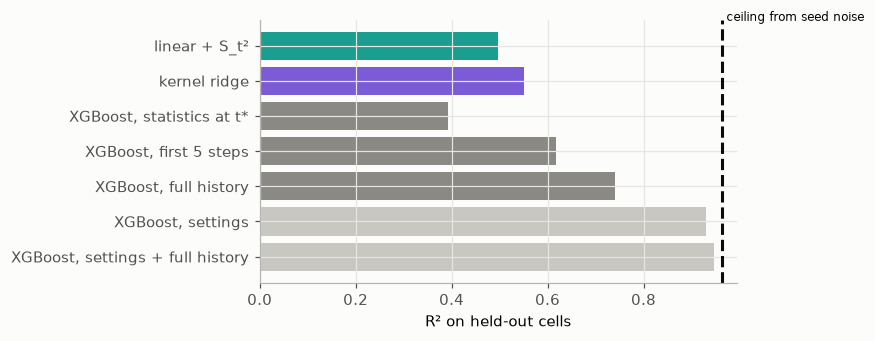

,R² on held-out cells,concordance on held-out cells,concordance on held-out alpha
linear + S_t²,0.497,0.766,0.670
kernel ridge,0.550,0.776,0.706
"XGBoost, statistics at t*",0.392,0.743,0.674
"XGBoost, first 5 steps",0.617,0.818,0.619
"XGBoost, full history",0.741,0.854,0.703
"XGBoost, settings",0.930,0.923,0.808
"XGBoost, settings + full history",0.947,0.939,0.770


In [15]:
XGB_GRID = [{'max_depth': d, 'eta': e, 'min_child_weight': w} for d, e, w in itertools.product([1, 2, 3, 4], [0.03, 0.1], [1, 5, 10])]
before = kern[kern['step'] <= T_STAR].pivot(index='run_id', columns='step', values=kernel)
history = np.stack([before[k].loc[data['run_id']].to_numpy() for k in kernel], axis=-1)     # runs × 25 saved steps × 3 statistics
settings = np.column_stack([np.log(data['alpha']), np.log(data['width']), np.log10(data['eta_kappa'].where(data['eta_kappa'] > 0, 1e-6))])
inputs = {'XGBoost, statistics at t*': history[:, -1, :], 'XGBoost, first 5 steps': history[:, :5, :].reshape(len(data), -1),
          'XGBoost, full history': history.reshape(len(data), -1), 'XGBoost, settings': settings,
          'XGBoost, settings + full history': np.hstack([settings, history.reshape(len(data), -1)])}
y, cells = log_T.to_numpy(), data['cell'].to_numpy()


def tuned_fold(X, train, test, seed=0):
    # Choose the settings on 20% of the training cells, refit on all training runs, and predict the test runs.
    train_cells = np.unique(cells[train])
    val = train & np.isin(cells, np.random.default_rng(seed).choice(train_cells, round(0.2 * len(train_cells)), replace=False))
    fit = train & ~val
    best = (np.inf, None, None)
    for setting in XGB_GRID:
        params = {'objective': 'reg:squarederror', 'subsample': 0.8, 'nthread': 1, 'seed': seed, **setting}
        booster = xgb.train(params, xgb.DMatrix(X[fit], label=y[fit]), 1000, evals=[(xgb.DMatrix(X[val], label=y[val]), 'validation')],
                            early_stopping_rounds=50, verbose_eval=False)
        if booster.best_score < best[0]:
            best = (booster.best_score, params, booster.best_iteration + 1)
    return test, xgb.train(best[1], xgb.DMatrix(X[train], label=y[train]), best[2]).predict(xgb.DMatrix(X[test]))


rows = {}
for name, X in inputs.items():
    rows[name] = {}
    for hide in ['cell', 'alpha']:
        folds = [((data[hide] != g).to_numpy(), (data[hide] == g).to_numpy()) for g in data[hide].unique()]
        p = np.zeros(len(data))
        for test, fold_pred in Parallel(n_jobs=-1)(delayed(tuned_fold)(X, train, test) for train, test in folds):
            p[test] = fold_pred
        if hide == 'cell':
            rows[name].update({'R² on held-out cells': r2_score(y, p), 'concordance on held-out cells': concordance_index(y, p)})
        else:
            rows[name]['concordance on held-out alpha'] = np.mean([concordance_index(y[data['alpha'] == a], p[data['alpha'] == a]) for a in sorted(data['alpha'].unique())])

earlier = pd.DataFrame({'R² on held-out cells': scores['R²'], 'concordance on held-out cells': scores['concordance'],
                        'concordance on held-out alpha': alpha_scores['mean concordance']}).loc[['linear + S_t²', 'kernel ridge']]
xgb_table = pd.concat([earlier, pd.DataFrame(rows).T])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(xgb_table.index, xgb_table['R² on held-out cells'], color=[KERNEL_COLOURS['S_t'], KERNEL_COLOURS['A_t'], GREY, GREY, GREY, PALE, PALE])
ax.axvline(1 - explained.loc['log T', 'seed noise'], color=INK, linestyle='--')
ax.text(1 - explained.loc['log T', 'seed noise'], -0.7, ' ceiling from seed noise', fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('R² on held-out cells')
plt.tight_layout()
plt.show()
xgb_table.round(3)

**What this shows**
- XGBoost on the statistics at $t^*$ (R² 0.392) does worse than kernel ridge (0.550). With 355 runs, trees give a coarser fit than a smooth surface.
- The first 5 saved steps explain more (0.617) than the statistics at $t^*$. Those steps come before any feature learning, so they mostly record the settings.
- The full history explains 0.741. The settings alone explain 0.930, and adding the history lifts this only to 0.947, close to the ceiling of 0.96.
- On a held-out `alpha` the settings also rank best (0.808), against 0.703 for the history and 0.706 for kernel ridge.
- So the history helps mainly because it records the settings. This matches notebook 3 (Part 5).

## Summary

| Question | Answer |
| --- | --- |
| How much is noise? | Little. Seed noise is 4% of the spread in $\log T$ and checkpoint rounding 0.03%, so the ceiling for $R^2$ is about 0.96. |
| What sets the statistics? | The settings. `S_t` and log `R_t` are 98.7% or more set by the cell, and `A_t` 56%. Within a cell they do not follow the seed noise. |
| Is the relation a straight line? | No. A straight line explains 31% on held-out cells. Non-linear models explain 50% to 55%. |
| What shape? | Two simple bends: `R_t` acts on a log scale, and `S_t` rises and falls. A linear model in `A_t`, `S_t`, `S_t`² and log `R_t` matches one free curve per statistic. `A_t` lowers the grokking step up to about 0.40. |
| Do the statistics interact? | A little among grokked runs: interaction terms lift the curves from 52% to 54%, and kernel ridge reaches 55%. They help most in deciding whether a run groks. |
| Which statistic carries the most? | `R_t`. Without it, kernel ridge falls from 55% to 23%. |
| Kernel or settings? | The settings. They explain 93%, against 55% for the best kernel model and 74% for the kernel's history. |

## How to model these data
1. Use log `R_t`.
2. Let `S_t` bend, with a square term or a spline. Trust the shape of `S_t` only below about 1.2, where all three values of `alpha` have runs.
3. Add interaction terms when the question includes runs that never grok. Among grokked runs they add little, and kernel ridge is the best model we tried.
4. Judge every model against two references: the ceiling of 0.96 from seed noise, and a model of the settings alone (0.93).

## Conclusion

Among runs that grok, the grokking step depends on the kernel statistics mainly through two simple bends: `R_t` acts on a log scale, and `S_t` rises and falls. Interactions add only a little here. Kernel ridge explains 55% of $\log T$ on held-out cells. Seed noise is small, so most of the remaining gap is signal that the statistics do not carry. The settings carry it: they explain 93%. `S_t` and `R_t` are close to a readout of the settings, and within a cell none of the statistics follows the seed noise.